Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20001 images belonging to 2 classes.
Epoch 1/20
5000/5000 [==============================] - 122s 24ms/step - loss: 0.2928 - accuracy: 0.8759 - val_loss: 0.2068 - val_accuracy: 0.9165
Epoch 2/20
5000/5000 [==============================] - 119s 24ms/step - loss: 0.2237 - accuracy: 0.9084 - val_loss: 0.1855 - val_accuracy: 0.9275
Epoch 3/20
5000/5000 [==============================] - 119s 24ms/step - loss: 0.1979 - accuracy: 0.9208 - val_loss: 0.1767 - val_accuracy: 0.9305
Epoch 4/20
5000/5000 [==============================] - 121s 24ms/step - loss: 0.1790 - accuracy: 0.9289 - val_loss: 0.1681 - val_accuracy: 0.9331
Epoch 5/20
5000/5000 [==============================] - 121s 24ms/step - loss: 0.1647 - accuracy: 0.9343 - val_loss: 0.1657 - val_accuracy: 0.9353
Epoch 6/20
5000/5000 [==============================] - 298s 60ms/step - loss: 0.1547 - accuracy: 0.9391 - val_loss: 0.1606 - val_accura

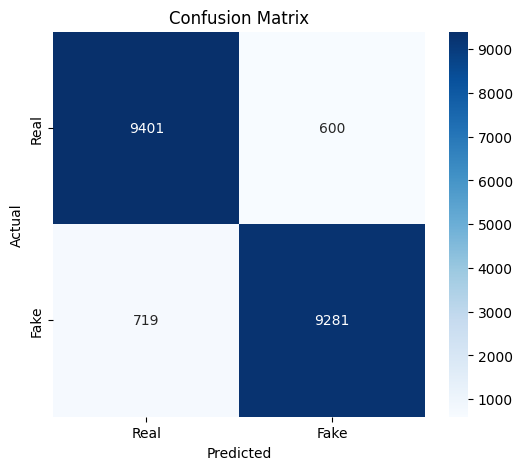

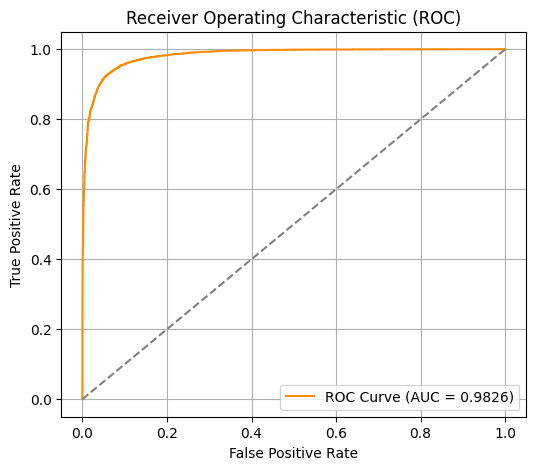

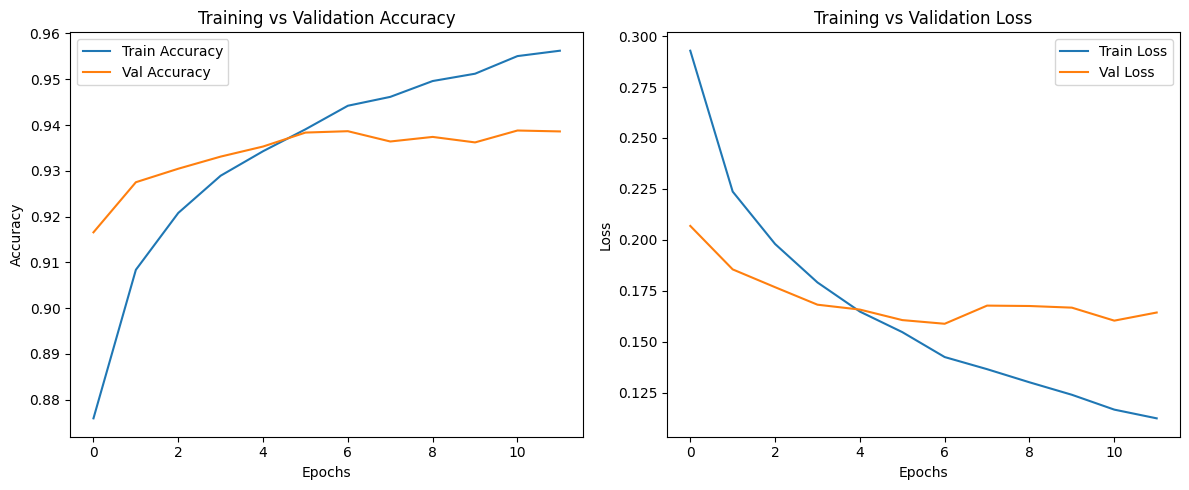

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Paths & Hyperparameters
DATASET_DIR = "data"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20

# Data generators with 20% validation split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

test_gen = datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "test"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Load ResNet152V2 base
base_model = ResNet152V2(weights='imagenet', include_top=False, input_shape=(*IMAGE_SIZE, 3))
base_model.trainable = False  # Freeze base model

# Custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint = ModelCheckpoint("resnet152v2_biomarker_best.h5", save_best_only=True)
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# Train model
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS,
                    callbacks=[checkpoint, early_stop])

# Save final model
model.save("resnet152v2_biomarker_final.h5")

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# Predictions
y_true = test_gen.classes
y_pred_prob = model.predict(test_gen).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification report
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy / Loss Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()
